# 02 — ngspice vs analytical

Created with Grok Build

Compare the ideal-VCVS and full **OPA365** macromodel AC response to the
analytical $H_{\mathrm{vin}}(s)$.

**Custom netlist:** replace the `simulate_ac(...)` calls with
`run_external_netlist(Path("your.cir"), workdir=...)` and parse your own
`wrdata` files (see comments in `opamp_design.simulate`).


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Directory that contains opamp_design/. Works when this notebook is run
# from the standalone repo (repo root or notebooks/) or from this website
# section (the folder that holds these notebooks and opamp_design/).
def _find_project_root() -> Path:
    start = Path.cwd().resolve()
    named = Path("Sections/Electronics/Analog_and_Digital/OPA365_Fig86")
    candidates = [start, *start.parents, start / named]
    if start.name == "notebooks":
        candidates.insert(0, start.parent)
    for cand in candidates:
        if (cand / "opamp_design" / "__init__.py").is_file():
            return cand
    return start

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from opamp_design.params import CircuitParams, OpampParams, ToleranceSpec, format_eng
from opamp_design import analysis, schematic

# -----------------------------------------------------------------------------
# EDITABLE PARAMETERS — change R/C/tolerances here for what-if studies.
# For a completely different netlist, keep these as documentation of the
# stimulus/supply and drive opamp_design.simulate.run_external_netlist(...)
# with your own .cir instead of the Fig. 8-6 generators.
# -----------------------------------------------------------------------------
R1 = 1.8e3       # ohms
R2 = 19.5e3
R3 = 150e3
C1 = 3.3e-9      # farads
C2 = 47e-12
C3 = 220e-12
R_TOL = 0.001    # 0.1% as fraction
C_TOL = 0.01     # 1% as fraction
V_SUPPLY = 5.0
V_IN_BIAS = 2.5
V_IN_PEAK = 2.5
F_DESIGN = 20e3

p = CircuitParams(
    R1=R1, R2=R2, R3=R3, C1=C1, C2=C2, C3=C3,
    r_tol=ToleranceSpec(R_TOL),
    c_tol=ToleranceSpec(C_TOL),
)
# Operating point overrides
from dataclasses import replace
p = replace(p, op=replace(p.op, v_supply=V_SUPPLY, v_in_bias=V_IN_BIAS,
                          v_in_peak=V_IN_PEAK, f_design_hz=F_DESIGN))

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
print("ROOT =", ROOT)
print("R1..C3 =", p.passive_dict())


ROOT = .
R1..C3 = {'R1': 1800.0, 'R2': 19500.0, 'R3': 150000.0, 'C1': 3.3e-09, 'C2': 4.7e-11, 'C3': 2.2e-10}


In [2]:
from opamp_design.simulate import simulate_ac, compare_ac_to_analytical, find_ngspice
from opamp_design.analysis import transfer_at_s

print("ngspice:", find_ngspice())

# --- Ideal op-amp + explicit non-ideal sources (fair match to analysis) ---
wd_ideal = ROOT / "results" / "ngspice_nom" / "ideal_ac"
ac_i = simulate_ac(
    p, opamp_model="ideal", workdir=wd_ideal, root=ROOT,
    mirror=ROOT / "netlists" / "spice_nom" / "fig86_ac_ideal.cir",
)

# --- TI OPA365 macromodel ---
wd_ic = ROOT / "results" / "ngspice_nom" / "opa365_ac"
ac_o = simulate_ac(
    p, opamp_model="opa365", workdir=wd_ic, root=ROOT,
    mirror=ROOT / "netlists" / "spice_nom" / "fig86_ac_opa365.cir",
)

def analytical_on_grid(f):
    return np.array([transfer_at_s(1j * 2 * np.pi * fi, p, "vin") for fi in f])

h_a_i = analytical_on_grid(ac_i.f_hz)
h_a_o = analytical_on_grid(ac_o.f_hz)
err_i = compare_ac_to_analytical(ac_i, h_a_i)
err_o = compare_ac_to_analytical(ac_o, h_a_o)
display(pd.DataFrame([{"model": "ideal", **err_i}, {"model": "OPA365", **err_o}]))

ngspice: ngspice


,model,max_abs_err_db,rms_err_db,max_abs_phase_err_deg
0,ideal,0.000013,0.000009,0.000016
1,OPA365,40.115125,7.979073,98.670288


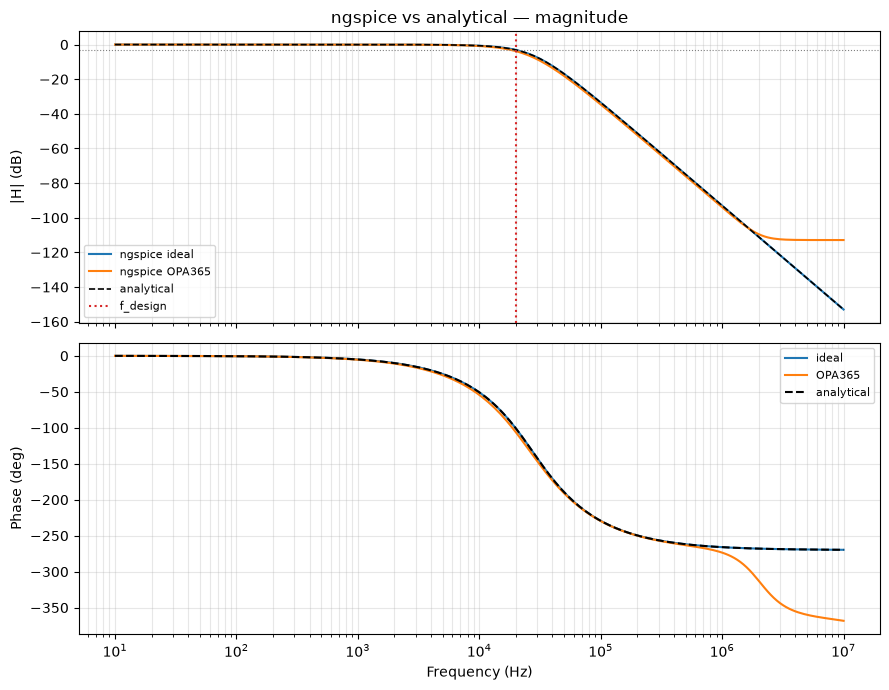

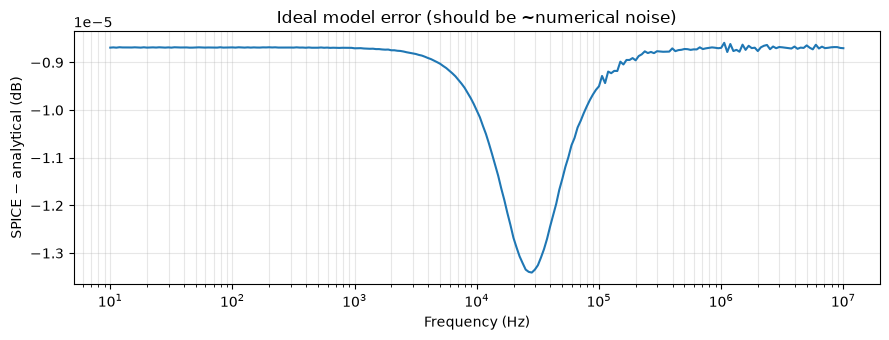

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ac, lab, c in (
    (ac_i, "ngspice ideal", "C0"),
    (ac_o, "ngspice OPA365", "C1"),
):
    axes[0].semilogx(ac.f_hz, ac.mag_db, label=lab, lw=1.5)
axes[0].semilogx(ac_i.f_hz, 20*np.log10(np.maximum(np.abs(h_a_i),1e-30)),
                 "k--", label="analytical", lw=1.2)
axes[0].axhline(-3, color="gray", ls=":", lw=0.8)
axes[0].axvline(p.op.f_design_hz, color="C3", ls=":", label="f_design")
axes[0].set_ylabel("|H| (dB)")
axes[0].set_title("ngspice vs analytical — magnitude")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)

for ac, lab in ((ac_i, "ideal"), (ac_o, "OPA365")):
    axes[1].semilogx(ac.f_hz, np.unwrap(np.angle(ac.h, deg=True)*np.pi/180)*180/np.pi, label=lab)
axes[1].semilogx(ac_i.f_hz, np.unwrap(np.angle(h_a_i))*180/np.pi, "k--", label="analytical")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (deg)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "02_ngspice_vs_analytical.png", dpi=150)
plt.show()

# Error vs frequency (ideal)
err_db = ac_i.mag_db - 20*np.log10(np.maximum(np.abs(h_a_i),1e-30))
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.semilogx(ac_i.f_hz, err_db)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("SPICE − analytical (dB)")
ax.set_title("Ideal model error (should be ~numerical noise)")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "02_ideal_error_db.png", dpi=150)
plt.show()